 # Retail Sales Performance Analysis using EDA

## The objective of this analysis is to understand sales patterns, profitability, and the impact of discounts on business performance.

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Global_Superstore2.csv" , encoding = 'latin1')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Market          51290 non-null  str    
 12  Region          51290 non-null  str    
 13  Product ID      51290 non-null  str    
 14  Category        51290 non-null  str    
 15  Sub-Category    51290 non-null  str    
 16  Product Name    51290 non-null  str    
 17  Sales           51290 non-null  float64
 1

In [6]:
df.shape

(51290, 23)

## . The dataset contains 51,290 records such as sales , profit , quantity , discount , discount , category , and order date.

In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

## No significant missing values were found in the dataset.

In [12]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [13]:
df.columns

Index(['row__id', 'order__id', 'order__date', 'ship__date', 'ship__mode',
       'customer__id', 'customer__name', 'segment', 'city', 'state', 'country',
       'market', 'region', 'product__id', 'category', 'sub-category',
       'product__name', 'sales', 'quantity', 'discount', 'profit',
       'shipping__cost', 'order__priority'],
      dtype='str')

In [32]:
df['order__date'] = pd.to_datetime(df['order__date'], format='%d-%m-%Y')
df['ship__date'] = pd.to_datetime(df['ship__date'] , format='%d-%m-%Y')

In [14]:
df.duplicated().sum()

np.int64(0)

In [20]:
df[['sales','profit','quantity']].describe()             #Numeric Summary

,sales,profit,quantity
count,51290.000000,51290.000000,51290.000000
mean,246.490581,28.610982,3.476545
std,487.565361,174.340972,2.278766
min,0.444000,-6599.978000,1.000000
25%,30.758625,0.000000,2.000000
50%,85.053000,9.240000,3.000000
75%,251.053200,36.810000,5.000000
max,22638.480000,8399.976000,14.000000


### Sales data is highly skewed with a mean of 246 and median of 85, indicating that most transactions are small but a few large orders significantly increase the average. Profit shows high variability with both positive and negative values, indicating inconsistent profitability.

In [23]:
df['category'].value_counts()

category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64

In [25]:
df.groupby('category')['profit'].sum()

category
Furniture          285204.72380
Office Supplies    518473.83430
Technology         663778.73318
Name: profit, dtype: float64

In [26]:
df.groupby('region')[['sales' , 'profit']].sum()

,sales,profit
region,,
Africa,7.837732e+05,88871.63100
Canada,6.692817e+04,17817.39000
Caribbean,3.242809e+05,34571.32104
Central,2.822303e+06,311403.98164
Central Asia,7.528266e+05,132480.18700
EMEA,8.061613e+05,43897.97100
East,6.787812e+05,91522.78000
North,1.248166e+06,194597.95252
North Asia,8.483098e+05,165578.42100


In [27]:
df[df['profit'] < 0]

,row__id,order__id,order__date,ship__date,ship__mode,customer__id,customer__name,segment,city,state,...,product__id,category,sub-category,product__name,sales,quantity,discount,profit,shipping__cost,order__priority
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
9,40936,CA-2012-116638,28-01-2012,31-01-2012,Second Class,JH-15985,Joseph Holt,Consumer,Concord,North Carolina,...,FUR-TA-10000198,Furniture,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124,865.74,Critical
30,220,US-2011-128776,28-12-2011,30-12-2011,Second Class,RR-19525,Rick Reed,Corporate,Santo Domingo,Santo Domingo,...,TEC-PH-10002815,Technology,Phones,"Samsung Smart Phone, VoIP",1696.640,5,0.2,-148.4600,704.06,Critical
32,32735,CA-2012-139731,15-10-2012,15-10-2012,Same Day,JE-15745,Joel Eaton,Consumer,Amarillo,Texas,...,FUR-CH-10002024,Furniture,Chairs,HON 5400 Series Task Chairs for Big and Tall,2453.430,5,0.3,-350.4900,690.42,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51276,31558,US-2014-155299,09-06-2014,13-06-2014,Standard Class,Dl-13600,Dorris liebe,Corporate,Pasadena,Texas,...,OFF-AP-10002203,Office Supplies,Appliances,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624,2,0.8,-4.4660,0.02,Medium
51278,43818,NI-2011-4700,08-09-2011,10-09-2011,Second Class,PO-8865,Patrick O'Donnell,Consumer,Lagos,Lagos,...,OFF-STA-10001791,Office Supplies,Art,"Stanley Highlighters, Water Color",5.364,1,0.7,-6.4560,0.02,High
51279,46231,ZI-2011-4350,21-03-2011,26-03-2011,Standard Class,AS-285,Alejandro Savely,Corporate,Harare,Harare,...,OFF-SAN-10001862,Office Supplies,Art,"Sanford Highlighters, Easy-Erase",9.612,2,0.7,-21.1680,0.02,Medium
51280,46582,TU-2014-6730,29-11-2014,30-11-2014,First Class,KF-6285,Karen Ferguson,Home Office,Midyat,Mardin,...,OFF-BOS-10000350,Office Supplies,Art,"Boston Pens, Blue",34.128,6,0.6,-49.5720,0.02,Medium


In [28]:
df[['sales' , 'profit']].corr()

,sales,profit
sales,1.000000,0.484918
profit,0.484918,1.000000


<Axes: xlabel='sales', ylabel='Count'>

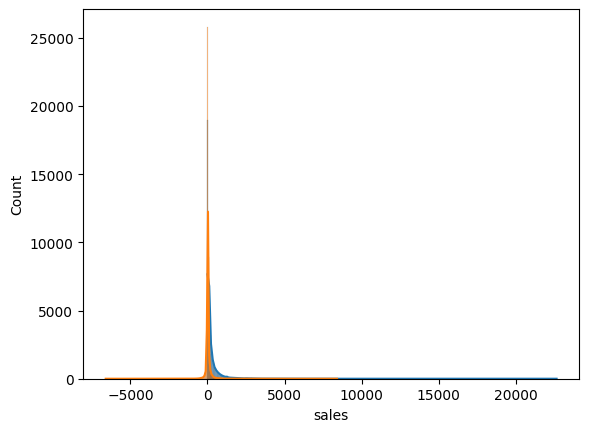

In [46]:
sns.histplot(df['sales'], kde=True)
sns.histplot(df['profit'], kde=True)

##

<Axes: xlabel='sales'>

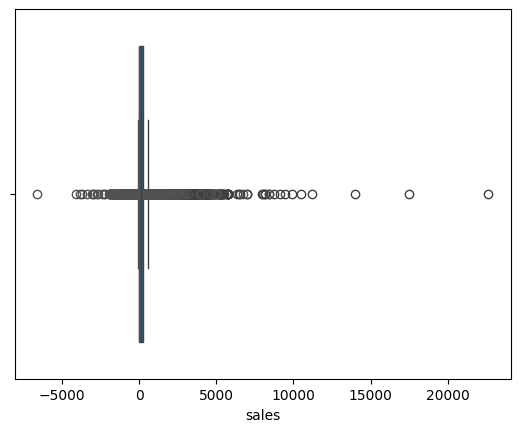

In [45]:
sns.boxplot(x=df['sales'])
sns.boxplot(x=df['profit'])

### Significant outliers are observed in both sales and profit.Extreme profit losses and very high sales values indicate the presence of unusual transactions.

<Axes: xlabel='sales', ylabel='profit'>

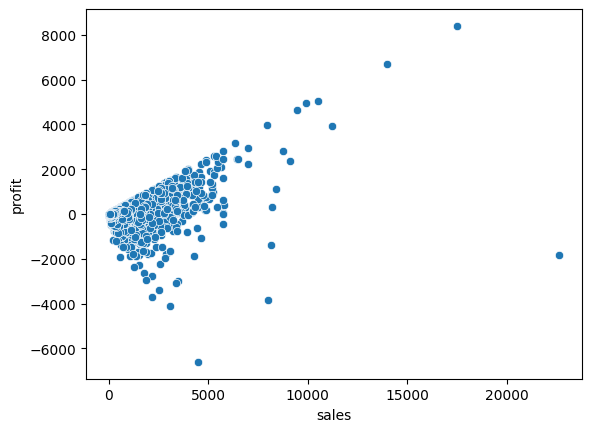

In [36]:
sns.scatterplot(x='sales' , y= 'profit' , data=df)

### A positive relationship exists between sales and profit, but higher sales do not always guarantee higher profit, especially when discounts are applied.

<Axes: xlabel='discount', ylabel='profit'>

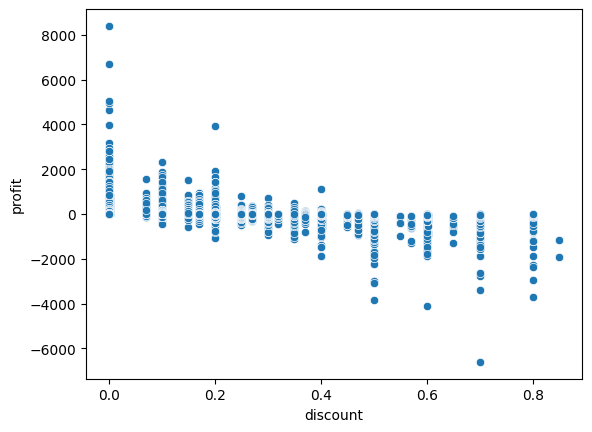

In [37]:
sns.scatterplot(x='discount', y='profit', data=df)

### Higher discounts are associated with lower profit and even losses, suggesting that aggressive discounting negatively impacts profitability.

<Axes: xlabel='category'>

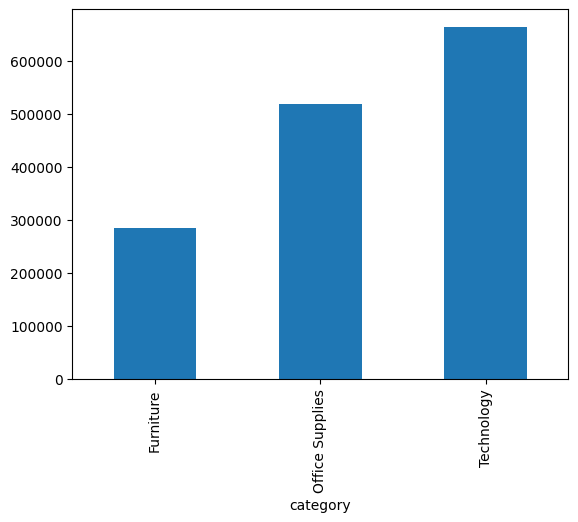

In [40]:
df.groupby('category')['profit'].sum().plot(kind='bar')

### Certain categories generate high sales but low profit, indicating inefficiencies in pricing or cost structure.

In [42]:
df.columns

Index(['row__id', 'order__id', 'order__date', 'ship__date', 'ship__mode',
       'customer__id', 'customer__name', 'segment', 'city', 'state', 'country',
       'market', 'region', 'product__id', 'category', 'sub-category',
       'product__name', 'sales', 'quantity', 'discount', 'profit',
       'shipping__cost', 'order__priority'],
      dtype='str')

<Axes: xlabel='order__date'>

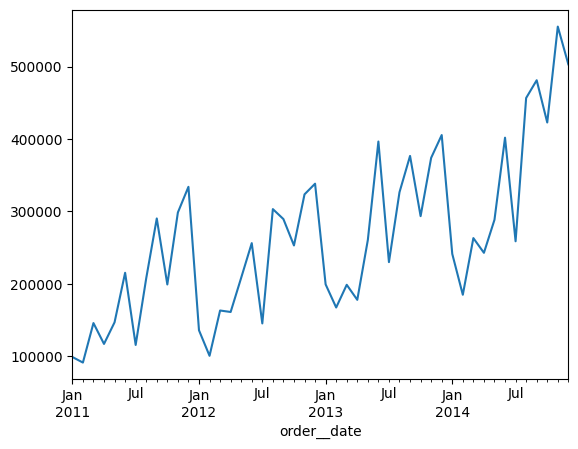

In [43]:
df.groupby(df['order__date'].dt.to_period('M'))['sales'].sum().plot()

### Sales show variation across months, indicating seasonal trends in customer purchasing behavior.

<Axes: >

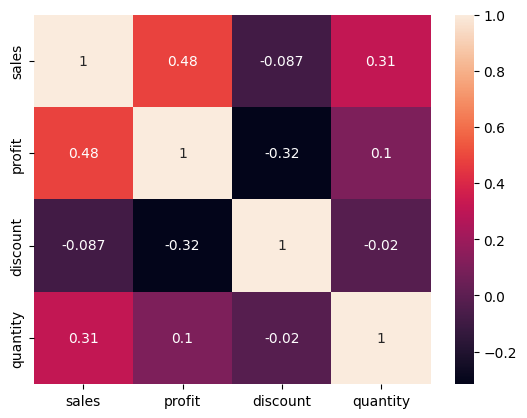

In [44]:
sns.heatmap(df[['sales','profit','discount','quantity']].corr(), annot=True)

### Sales and profit show a moderate positive correlation, while discount negatively impacts profit.